# Random Forest — Finance Risk Scoring (Realistic Synthetic Generator)

When a public finance dataset isn't bundled with the repo, we generate a realistic tabular dataset with: nonlinearities, interactions, noise, and class imbalance.

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Generate a realistic credit-risk dataset

Build a realistic synthetic dataset when a public dataset isn't bundled (keeps repo self-contained).

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(SEED)
n = 8000

age = rng.integers(18, 75, size=n)
income = rng.lognormal(mean=10.5, sigma=0.5, size=n)  # ~ yearly income
debt = rng.lognormal(mean=9.8, sigma=0.6, size=n)
employment_years = np.clip(rng.normal(8, 6, size=n), 0, 40)
credit_history_years = np.clip(rng.normal(10, 7, size=n), 0, 45)
num_late_payments = rng.poisson(0.6, size=n)
utilization = np.clip(rng.beta(2, 5, size=n), 0, 1)
region = rng.choice(['EU', 'NA', 'APAC'], p=[0.45, 0.35, 0.20], size=n)

df = pd.DataFrame({
    'age': age,
    'income': income,
    'debt': debt,
    'employment_years': employment_years,
    'credit_history_years': credit_history_years,
    'num_late_payments': num_late_payments,
    'utilization': utilization,
    'region': region,
})

# Nonlinear log-odds model for default
logit = (
    -6.0
    + 0.03*(df['age'] < 23).astype(float)
    + 0.9*np.log1p(df['debt'])
    - 0.8*np.log1p(df['income'])
    + 1.8*df['utilization']
    + 0.35*df['num_late_payments']
    - 0.04*df['credit_history_years']
    + 0.015*(df['debt']/np.maximum(df['income'], 1))
)
# Region effects
logit += df['region'].map({'EU': -0.05, 'NA': 0.10, 'APAC': 0.20}).astype(float)

p = 1/(1 + np.exp(-logit))
y = (rng.uniform(size=n) < p).astype(int)
df['default'] = y

display(df.head())
print('Default rate:', df['default'].mean())


,age,income,debt,employment_years,credit_history_years,num_late_payments,utilization,region,default
0,23,21583.827202,15610.316604,24.065919,3.250246,0,0.337640,EU,0
1,62,17182.896210,15463.285791,14.424933,15.411314,0,0.384421,NA,0
2,55,71417.409910,6936.894838,11.095297,1.733856,0,0.501065,EU,0
3,43,121932.629081,17260.550974,11.453354,4.436539,0,0.131650,APAC,0
4,42,28627.567763,5217.292485,19.037226,18.371421,2,0.264184,EU,0


Default rate: 0.009375


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,8000.0,NaN,NaN,NaN,45.727875,16.432303,18.0,31.0,46.0,60.0,74.0
income,8000.0,NaN,NaN,NaN,41095.396843,22364.060505,4045.832863,25888.990864,35905.924511,50568.309927,289416.092633
debt,8000.0,NaN,NaN,NaN,21923.577187,14160.778596,1749.906077,12163.399189,18193.726185,27493.290488,123025.35955
employment_years,8000.0,NaN,NaN,NaN,8.418225,5.562674,0.0,4.142669,8.200634,12.142802,30.095057
credit_history_years,8000.0,NaN,NaN,NaN,10.209455,6.582175,0.0,5.221401,9.959962,14.728096,38.615461
num_late_payments,8000.0,NaN,NaN,NaN,0.611375,0.777767,0.0,0.0,0.0,1.0,5.0
utilization,8000.0,NaN,NaN,NaN,0.285335,0.158865,0.002777,0.161333,0.26564,0.387079,0.894042
region,8000,3,EU,3611,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,8000.0,NaN,NaN,NaN,0.009375,0.096376,0.0,0.0,0.0,0.0,1.0


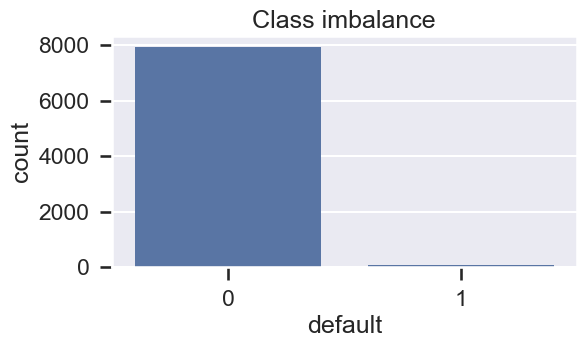

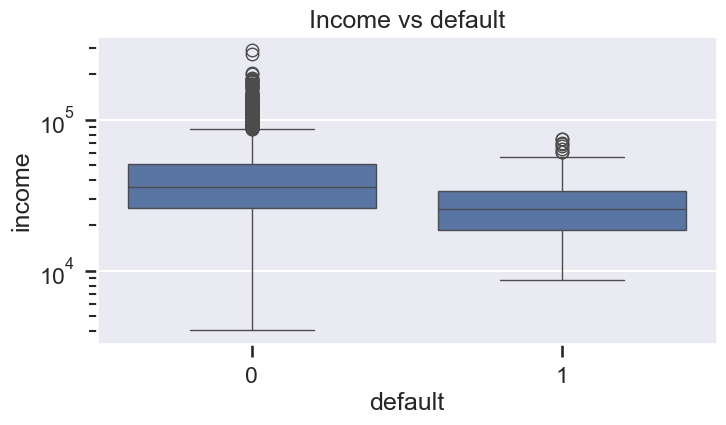

In [3]:
# Numerical summary
display(df.describe(include='all').T.head(20))

plt.figure(figsize=(6,3))
sns.countplot(x='default', data=df)
plt.title('Class imbalance')
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x='default', y='income', data=df)
plt.yscale('log')
plt.title('Income vs default')
plt.show()


## Feature engineering + modeling

In [4]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

X = df.drop(columns=['default'])
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

num_cols = ['age','income','debt','employment_years','credit_history_years','num_late_payments','utilization']
cat_cols = ['region']

num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])
cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))])

ct = ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

baseline = Pipeline([('prep', ct), ('model', DummyClassifier(strategy='most_frequent'))])
logreg = Pipeline([('prep', ct), ('model', LogisticRegression(max_iter=5000, solver='liblinear', random_state=SEED))])
rf = Pipeline([('prep', ct), ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Tune RF (a few key params)
space = {
    'model__n_estimators': [200, 400, 700],
    'model__max_depth': [None, 4, 8, 12],
    'model__min_samples_leaf': [1, 5, 15, 30],
    'model__max_features': ['sqrt', 0.5, 1.0],
    'model__class_weight': [None, 'balanced'],
}
rf_rs = RandomizedSearchCV(rf, space, n_iter=20, scoring='roc_auc', cv=cv, n_jobs=-1, random_state=SEED)
rf_rs.fit(X_train, y_train)

print('Best RF AUC (CV):', rf_rs.best_score_)
print('Best params:', rf_rs.best_params_)

# Evaluate vs baselines
for name, model in [('dummy', baseline), ('logreg', logreg), ('rf_tuned', rf_rs.best_estimator_)]:
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    print(name, 'AUC:', roc_auc_score(y_test, proba))


Best RF AUC (CV): 0.7322160883280757
Best params: {'model__n_estimators': 700, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 8, 'model__class_weight': None}
dummy AUC: 0.5
logreg AUC: 0.6937539432176656
rf_tuned AUC: 0.757602523659306


## Interpretation: feature importances

Use feature importance to sanity-check that the model learned plausible drivers.

,feature,importance
2,debt,0.223468
1,income,0.191583
6,utilization,0.172698
3,employment_years,0.124351
4,credit_history_years,0.113827
0,age,0.104329
5,num_late_payments,0.038865
8,region_EU,0.012525
7,region_APAC,0.009297
9,region_NA,0.009056


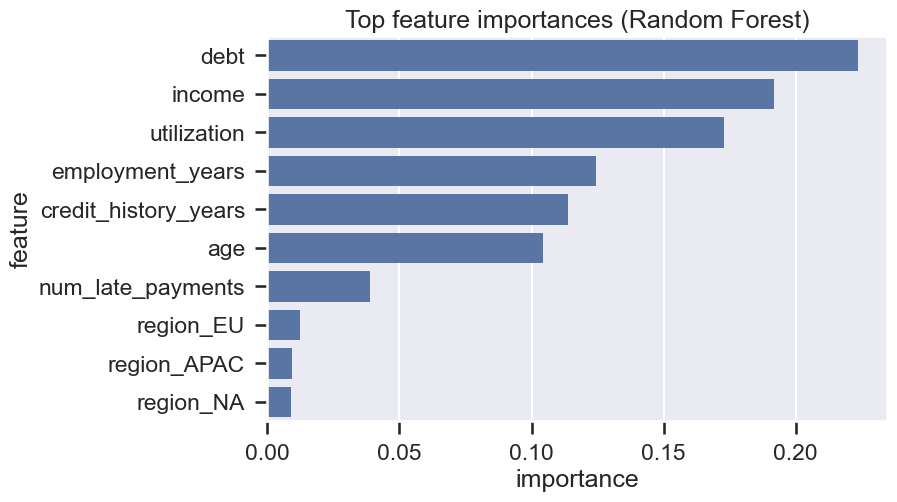

In [5]:
import numpy as np

best = rf_rs.best_estimator_
best.fit(X_train, y_train)

# Get expanded feature names
ohe = best.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
feature_names = num_cols + ohe.get_feature_names_out(cat_cols).tolist()
importances = best.named_steps['model'].feature_importances_

imp = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)
display(imp)

plt.figure(figsize=(8,5))
sns.barplot(data=imp, x='importance', y='feature')
plt.title('Top feature importances (Random Forest)')
plt.show()
